<a href="https://colab.research.google.com/github/DhaviRodrigues/Projeto_PISI3_2026/blob/main/head_tail_paises_avaliacoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

sns.set_theme(style="whitegrid")

# 2. Ingestão e Limpeza de Dados
Carregamento do dataset do IMDb e remoção de valores nulos, mantendo os registros com zero votos para análise da Cauda Longa profunda.

In [ ]:
arquivos = [f for f in os.listdir('/content') if f.endswith('.csv')]
caminho = '/content/' + arquivos[0]
df = pd.read_csv(caminho)

df.columns = [c.strip().lower() for c in df.columns]
col_votos = 'vote_count' if 'vote_count' in df.columns else [c for c in df.columns if 'vote' in c][0]

df = df.dropna(subset=[col_votos])
df_sorted = df.sort_values(by=col_votos, ascending=False).reset_index(drop=True)
df_sorted['Ranking'] = range(1, len(df_sorted) + 1)

# 3. Análise Estatística: Head/Tail Breaks
Cálculo da Média Aritmética Global para isolar a assimetria da distribuição e identificar o ponto de ruptura do mercado.

In [ ]:
media_global = df_sorted[col_votos].mean()
corte_index = len(df_sorted[df_sorted[col_votos] >= media_global])

print(f"Total de filmes: {len(df_sorted):,}")
print(f"Média Global: {media_global:.2f} votos")
print(f"Ponto de Corte (Ranking): {corte_index:,}")

Total de filmes: 951,555
Média Global: 22.51 votos
Ponto de Corte (Ranking): 46,038


# 4. Análise dos Países no Segmento 'Cabeça' (Mainstream)

Identificação dos países que se enquadram no segmento 'Cabeça' (mainstream) e discussão sobre o possível viés no dataset.


In [ ]:
countries_in_head = df_countries_sorted.head(corte_index_countries)

print("Países no segmento 'Cabeça' (Mainstream) de filmes:")
print(countries_in_head)

Países no segmento 'Cabeça' (Mainstream) de filmes:
                     country  count_of_movies  Ranking
0   United States of America           143725        1
1                     France            40289        2
2             United Kingdom            37102        3
3                    Germany            36459        4
4                      Japan            34251        5
5                     Canada            20017        6
6                      India            19833        7
7                      Italy            17032        8
8                     Brazil            14677        9
9                      Spain            13803       10
10                    Mexico            11947       11
11                     China             9501       12
12                    Russia             9318       13
13              Soviet Union             8690       14
14               South Korea             8554       15
15                 Argentina             8012       16
16           

# 5. Visualização da Produção dos Top 10 Países na 'Head'

Gráfico de barras para comparar a quantidade de filmes produzidos pelos 10 países mais representativos no segmento 'Head', evidenciando a concentração da produção.

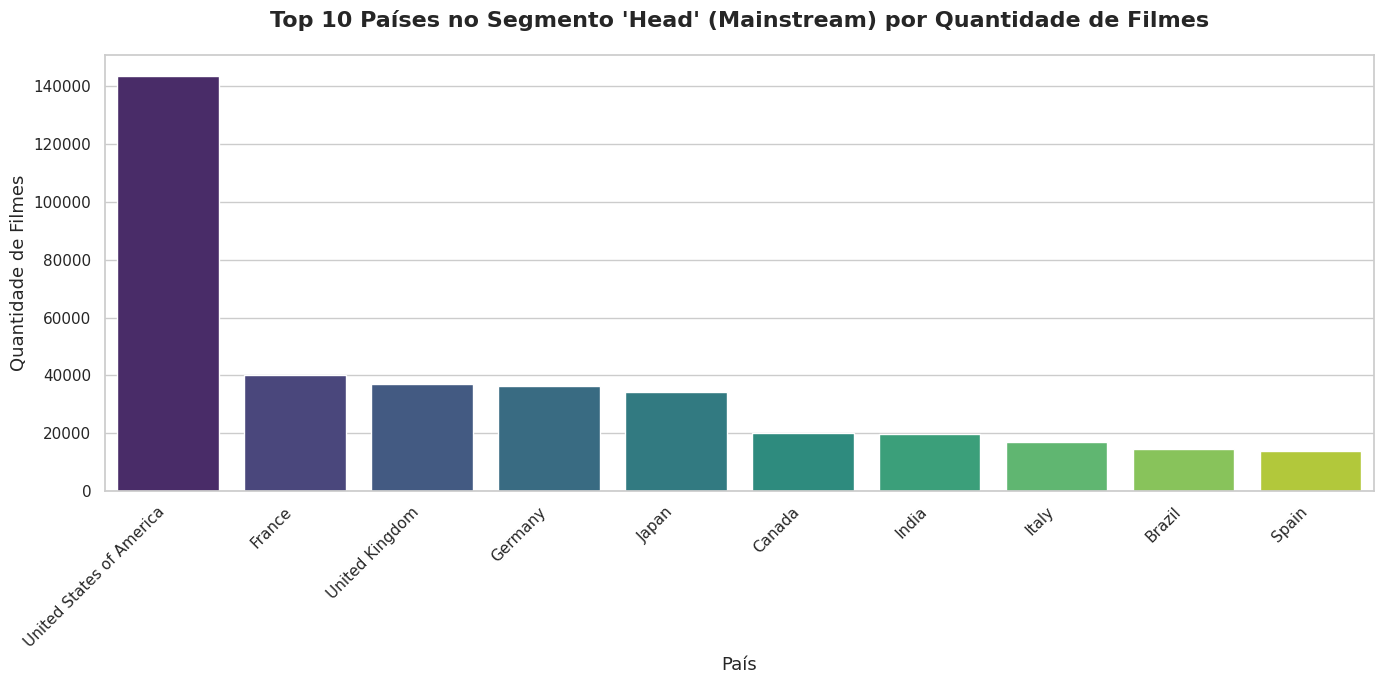

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='country', y='count_of_movies', data=countries_in_head.head(10), palette='viridis', hue='country', legend=False)

plt.title('Top 10 Países no Segmento \'Head\' (Mainstream) por Quantidade de Filmes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('País', fontsize=13)
plt.ylabel('Quantidade de Filmes', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Avaliação de Qualidade: Head vs. Tail

Embora o segmento 'Head' domine o volume de votos e a visibilidade, analisamos se essa popularidade se traduz em notas superiores. O Boxplot abaixo compara a distribuição das notas médias (`vote_average`) entre os dois segmentos. Foi Realizado um tratamento de nulos por Inputação Proporcional, onde foi analizado a proporção de notas dentro do dataset, e replicando os valores seguindo a proporção para todos os valores nulos, assim não distorcendo a qualidade estatística do dataset.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_rated = df_sorted[df_sorted[col_votos] > 0].copy()

media_rated = df_rated[col_votos].mean()
corte_rated = len(df_rated[df_rated[col_votos] >= media_rated])

df_head_qualidade = df_rated.iloc[:corte_rated].copy()
df_tail_qualidade = df_rated.iloc[corte_rated:].copy()

df_head_qualidade['Segmento'] = 'Mainstream (Head)'
df_tail_qualidade['Segmento'] = 'Alternativo (Tail)'


In [ ]:
import numpy as np

notas_disponiveis = df_rated['vote_average'].values

num_zeros = len(df_sorted[df_sorted[col_votos] == 0])
notas_imputadas = np.random.choice(notas_disponiveis, size=num_zeros)

df_sorted['vote_average_imputed'] = df_sorted['vote_average']
mask_zero = df_sorted[col_votos] == 0
df_sorted.loc[mask_zero, 'vote_average_imputed'] = notas_imputadas


Mediana Head (Integral): 6.37
Mediana Tail (Integral): 6.00


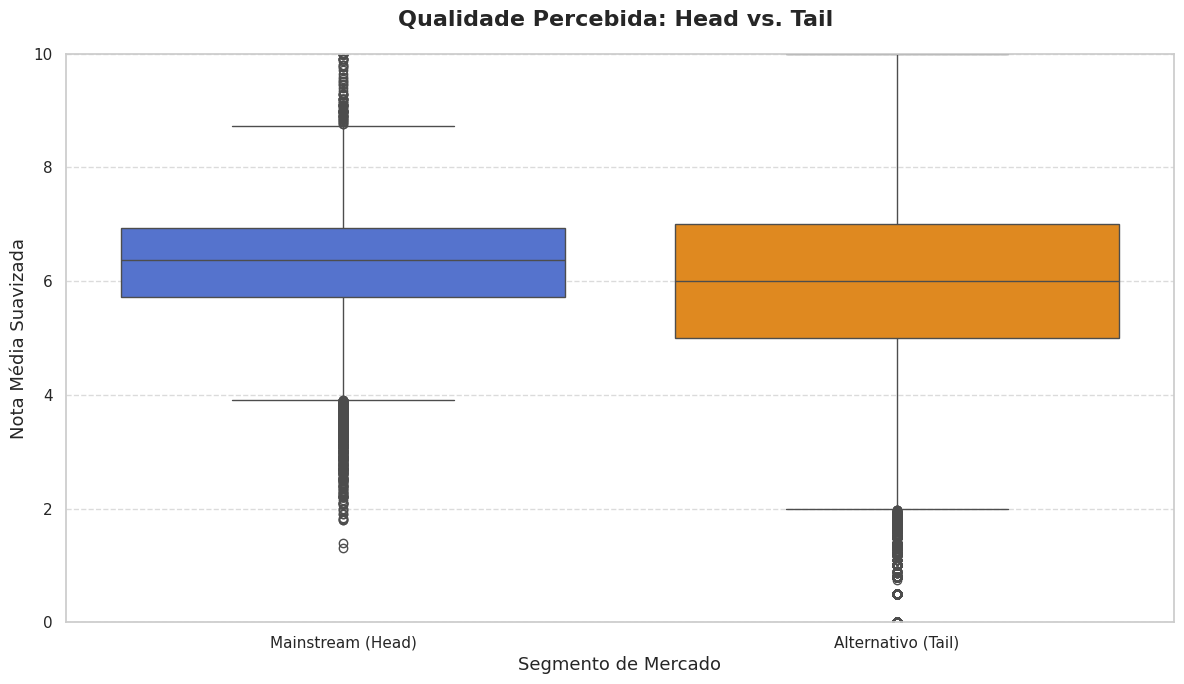

In [ ]:
df_head_full = df_sorted.iloc[:corte_index].copy()
df_tail_full = df_sorted.iloc[corte_index:].copy()

df_head_full['Segmento'] = 'Mainstream (Head)'
df_tail_full['Segmento'] = 'Alternativo (Tail)'

df_qualidade_full = pd.concat([df_head_full, df_tail_full])

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_qualidade_full, x='Segmento', y='vote_average_imputed',
            palette=['royalblue', 'darkorange'], hue='Segmento', legend=False)

plt.title('Qualidade Percebida: Head vs. Tail ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Segmento de Mercado', fontsize=13)
plt.ylabel('Nota Média Suavizada', fontsize=13)
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

med_h = df_head_full['vote_average_imputed'].median()
med_t = df_tail_full['vote_average_imputed'].median()

print(f"Mediana Head (Integral): {med_h:.2f}")
print(f"Mediana Tail (Integral): {med_t:.2f}")

plt.tight_layout()
plt.show()